# Trajectory Analysis across models for Suo et. al.

In [1]:
0

0

In [2]:
import sys
working_directory = "/home/icb/kemal.inecik/work/codes/sctram"
sys.path.append(working_directory)

import logging
import subprocess
import gc
import os
import time
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
from sklearn.preprocessing import MinMaxScaler
import scipy.stats as stats
import itertools

sc.settings.verbose = 3

In [3]:
from sctram.api._lower_level import TrajectoryEvaluationAPI
from sctram.input import InputTrajectories
from sctram.generate.real import sc_suo_developmental_complete

2025-03-02 16:28:03.907 | INFO     | sctram.api._defaults_read:load_default_metrics:23 - Loaded default metrics from /home/icb/kemal.inecik/work/codes/sctram/sctram/api/_defaults.yaml
2025-03-02 16:28:03.908 | INFO     | sctram.api._defaults_read:load_default_metrics:79 - Default metrics YAML structure validated successfully.


In [267]:
# Important to have consistent figures across platforms

%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib import gridspec
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import colorcet as cc
from adjustText import adjust_text  
import matplotlib.patheffects as path_effects

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [5]:
dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
helpers_directory = os.path.join(os.getcwd(), "helper")
logs_directory = os.path.join(os.getcwd(), "logs")
adata_suo_complete = sc_suo_developmental_complete(dataset_dir=dataset_dir)

2025-03-02 16:28:06.462 | WARNING  | sctram.generate.real._download:download_dataset:105 - File PosixPath('/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/suo_developmental_complete.h5ad') already exists. Skipping download.


In [6]:
input_trajectories_path = os.path.join(dataset_dir, f"adata_suo_input_haematopoeitic_lineage.pkl")
with open(input_trajectories_path, "rb") as _file:
    lit = pickle.load(_file)

In [289]:
def plot_obsms(lin, plot_obs, adata, label_on_data=False, n_cols=4, subplot_size=(5, 4), prevent_bottom_legend=False, coefficient=1.0):
    # Collect all categories and their global counts for consistent coloring
    lin = lin.replace('_lineage', '').lower()
    global_counts = {}
    
    # First pass to get all categories and their global counts
    for use_rep in adata[lin]:
        adata_obj = adata[lin][use_rep]
        counts = adata_obj.obs[plot_obs].astype(str).value_counts().to_dict()
        for cat, count in counts.items():
            global_counts[cat] = global_counts.get(cat, 0) + count
        break  # as all the reps have the same anndata.obs
    
    # Sort categories by global abundance descending
    unique_lvl = sorted(global_counts.keys(), key=lambda x: -global_counts[x])
    
    # Create color mapping based on global abundance
    n_cats = len(unique_lvl)
    palette = sns.color_palette(cc.glasbey_category10, n_cats)
    lvl_to_color = {cat: palette[i] for i, cat in enumerate(unique_lvl)}
    
    # Plotting parameters
    n_cols = n_cols
    subplot_size = subplot_size
    legend_ncol = 4
    
    use_reps = list(adata[lin].keys())
    if not use_reps:
        raise ValueError(f"no obsm for {lin!r}")
        
    n_subplots = len(use_reps)
    n_rows = int(np.ceil(n_subplots / n_cols))
    n_datapoints = len(next(iter(adata[lin].values())))  # Get count from first adata_obj
    
    # Dynamic point size calculation
    base_size = 1e5
    s = base_size / n_datapoints * coefficient
    
    # Figure setup
    fig_width = subplot_size[0] * n_cols
    fig_height = subplot_size[1] * n_rows + 2
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = gridspec.GridSpec(n_rows, n_cols, figure=fig)
    
    # Plot each use_rep with local abundance ordering
    for idx, use_rep in enumerate(use_reps):
        ax = fig.add_subplot(gs[idx // n_cols, idx % n_cols])
        adata_obj = adata[lin][use_rep]
        umap_coords = adata_obj.obsm['X_umap']
        
        # Get local counts for layering order
        local_counts = adata_obj.obs[plot_obs].astype(str).value_counts().sort_values(ascending=False)
        sorted_cats = local_counts.index.tolist()
        
        # Plot each category in abundance order (large to small)
        for cat in sorted_cats:
            mask = adata_obj.obs[plot_obs].astype(str) == cat
            ax.scatter(
                umap_coords[mask, 0],
                umap_coords[mask, 1],
                s=s,
                c=[lvl_to_color[cat]],
                alpha=0.4,
                linewidth=s*0.3,
                # rasterized=True,
                edgecolor='none'
            )
        
        # Add labels on data if enabled
        if label_on_data:
            texts = []
            centroid_info = []  # Stores (centroid, color) for each label
            
            for cat in sorted_cats:
                mask = adata_obj.obs[plot_obs].astype(str) == cat
                coords = umap_coords[mask]
                if len(coords) == 0:
                    continue
                
                # Compute centroid with outlier removal
                initial_centroid = np.mean(coords, axis=0)
                distances = np.linalg.norm(coords - initial_centroid, axis=1)
                std = np.std(distances)
                if std == 0:
                    final_centroid = initial_centroid
                else:
                    threshold = 3.0 * std
                    filtered = distances <= threshold
                    filtered_coords = coords[filtered]
                    final_centroid = np.mean(filtered_coords, axis=0) if len(filtered_coords) > 0 else initial_centroid
                
                # Plot enlarged centroid point
                ax.scatter(
                    final_centroid[0], final_centroid[1],
                    s=30*s,  # 10x normal size
                    c=[lvl_to_color[cat]],
                    alpha=1.0,
                    edgecolor='white',
                    linewidth=s*1,
                    zorder=5
                )
                
                # Create squeezed text using LaTeX \scalebox
                txt = ax.text(
                    final_centroid[0], final_centroid[1],
                    cat,
                    fontsize=6,
                    weight='bold',  # Make text bold
                    ha='center',
                    va='center',
                    color="black", #lvl_to_color[cat],
                    zorder=6
                )
                # Add a white outline effect around the text
                txt.set_path_effects([
                    path_effects.Stroke(linewidth=0.5, foreground='white'),
                    path_effects.Normal()
                ])
                
                texts.append(txt)
                centroid_info.append((final_centroid, lvl_to_color[cat]))
            
            # Adjust text positions without automatic arrows
            if texts:
                adjust_text(
                    texts, 
                    ax=ax,
                    force_text=(0.3, 0.3),   # Increase these values for stronger text movement
                    force_points=(1.8, 1.8),
                    lim=500
                )
                
                # Add manual colored arrows
                for txt, (centroid, color) in zip(texts, centroid_info):
                    # Get the text bounding box in data coordinates
                    renderer = fig.canvas.get_renderer()
                    bbox = txt.get_window_extent(renderer=renderer)
                    bbox_data = ax.transData.inverted().transform(bbox)
                    
                    # Calculate the center of the text bounding box
                    text_center = [
                        (bbox_data[0, 0] + bbox_data[1, 0]) / 2,  # x-center
                        (bbox_data[0, 1] + bbox_data[1, 1]) / 2   # y-center
                    ]
                    
                    # Draw arrow from centroid to text center
                    ax.annotate(
                        '',
                        xy=centroid,  # Arrow points to text center
                        xytext=text_center,  # Arrow starts at centroid
                        arrowprops=dict(
                            arrowstyle='->',
                            color="black", #color,
                            lw=0.5,
                            alpha=1,
                            connectionstyle="arc3,rad=0.15"  # Adjust curvature as needed
                        ),
                        zorder=4
                    )
        
        # Subplot formatting
        ax.set_title(use_rep, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines[:].set_visible(False)

    if not label_on_data and not prevent_bottom_legend:
        # Create unified legend only if labels are not on data
        legend_handles = [
            plt.Line2D([0], [0], 
             marker='o', 
             color='w', 
             markerfacecolor=lvl_to_color[cat], 
             markersize=10,
             label=f"{cat} ({global_counts[cat]:,})")
            for cat in unique_lvl
        ]
        
        fig.legend(
            handles=legend_handles,
            loc='lower center',
            ncol=legend_ncol,
            bbox_to_anchor=(0.5, -0.05),
            frameon=False,
            fontsize=10,
            handletextpad=0.1
        )

    # Final layout adjustments
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    fig.suptitle(f"{lin} - {plot_obs}", y=0.98, fontsize=12)
    plt.show()

In [278]:
def plot_trajectory(
        graph,
        title,
        figsize=(12, 4),
        font_size=10,
        node_size=300,
        node_color='#8DA0CB',  # Modern muted blue
        cmap='viridis',
        color_nodes_by_position=False,
        # Edge styling parameters
        edge_width=1,
        edge_color='gray',
        color_edges_by_weight=False,
        edge_weight_attribute='weight',
        edge_cmap='plasma',
        edge_vmin=None,
        edge_vmax=None,
        edge_colorbar=True,
        edge_labels=False,
        edge_label_format='.2f',
        edge_label_font_size=8,
        edge_label_color='black',
        edge_label_offset=10,
        # Layout parameters
        label_offset=25,
        title_y=1.02,
        layout_args="-Grankdir=LR -Gnodesep=1.0 -Granksep=2.5"
    ):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    # Calculate hierarchical layout
    pos = nx.nx_agraph.graphviz_layout(graph, prog="dot", args=layout_args)

    # Node coloring logic
    if color_nodes_by_position:
        try:
            xs = [pos[node][0] for node in graph.nodes]
            min_x, max_x = min(xs), max(xs)
            color_vals = [(x - min_x)/(max_x - min_x) if max_x != min_x else 0.5 for x in xs]
            node_color = plt.get_cmap(cmap)(color_vals)
        except Exception as e:
            print(f"Warning: Positional coloring failed - {e}. Using base color.")

    # Edge coloring logic
    if color_edges_by_weight:
        weights = [graph[u][v].get(edge_weight_attribute, 1.0) for u, v in graph.edges]
        edge_vmin = edge_vmin if edge_vmin is not None else (min(weights) if weights else 0)
        edge_vmax = edge_vmax if edge_vmax is not None else (max(weights) if weights else 1)
        norm = mpl.colors.Normalize(vmin=edge_vmin, vmax=edge_vmax)
        cmap_edge = plt.get_cmap(edge_cmap)
        edge_colors = [cmap_edge(norm(w)) for w in weights]
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_edge)
        sm.set_array(weights)
    else:
        edge_colors = edge_color
        sm = None

    # Calculate label positions for nodes
    label_pos = {n: (x, y + label_offset) for n, (x, y) in pos.items()}

    # Draw network elements
    nx.draw_networkx_nodes(
        graph, pos, ax=ax,
        node_size=node_size,
        node_color=node_color,
        edgecolors='black',
        linewidths=0.8,
        alpha=1.0
    )

    nx.draw_networkx_edges(
        graph, pos, ax=ax,
        arrowstyle='-|>',
        arrowsize=15,
        edge_color=edge_colors,
        width=edge_width,
        alpha=1.0,
        connectionstyle='arc3'
    )

    # Add edge labels if requested
    if edge_labels:
        for u, v in graph.edges():
            if edge_weight_attribute not in graph[u][v]:
                continue
            weight = graph[u][v][edge_weight_attribute]
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            
            # Calculate midpoint with offset
            dx = x2 - x1
            dy = y2 - y1
            length = (dx**2 + dy**2)**0.5
            
            if length == 0:
                continue  # Skip self-loops
                
            mid_x = (x1 + x2)/2 + (dy/length)*edge_label_offset
            mid_y = (y1 + y2)/2 - (dx/length)*edge_label_offset
            
            ax.text(
                mid_x, mid_y,
                f"{weight:{edge_label_format}}",
                fontsize=edge_label_font_size,
                color=edge_label_color,
                ha='center', va='center',
                bbox=dict(
                    boxstyle="round",
                    facecolor="white",
                    alpha=0.8,
                    edgecolor="none"
                )
            )

    nx.draw_networkx_labels(
        graph, label_pos, ax=ax,
        font_size=font_size,
        font_weight='normal',
        font_family=plt.rcParams['font.family'],
        alpha=1.0
    )

    # Add colorbar if needed
    if color_edges_by_weight and edge_colorbar and sm:
        cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', 
                           shrink=0.3, aspect=40, pad=0.05)
        cbar.set_label('Edge Weight', fontsize=font_size)
        cbar.ax.tick_params(labelsize=font_size-2)

    # Add styled title
    fig.suptitle(
        title,
        y=title_y,
        fontsize=font_size + 2,
        fontweight='bold',
        color='#333333'
    )

    # Configure final layout
    plt.subplots_adjust(
        left=0.03,
        right=0.97,
        top=0.88 if title else 0.97,
        bottom=0.15 if (color_edges_by_weight and edge_colorbar) else 0.03
    )
    ax.set_axis_off()
    plt.show()

In [279]:
def create_dynamic_boxswarm_plot(df, fig_height = 6):
    # Calculate figure dimensions based on number of columns
    n_cols = df.shape[1]
    col_width = 0.8  # Width per column in inches
    fig_width = n_cols * col_width
    # fig_height = 8  # Fixed height for better vertical readability
    
    # Create figure with dynamic width
    plt.figure(figsize=(fig_width, fig_height))
    
    # Create boxplot with refined styling
    bp = sns.boxplot(data=df,
                     width=0.7,
                     flierprops=dict(marker='o', markersize=4, markeredgecolor='black', alpha=0.6),
                     boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.5),
                     whiskerprops=dict(color='black', linewidth=1.5),
                     medianprops=dict(color='darkred', linewidth=2),
                     capprops=dict(color='black', linewidth=1.5),
                     saturation=1,
                     zorder=1)
    
    # Add swarmplot with sophisticated aesthetics
    sp = sns.swarmplot(data=df,
                       size=4,
                       palette='dark:black',
                       edgecolor='white',
                       linewidth=0.5,
                       alpha=0.8,
                       marker='o',
                       zorder=2)
    
    # Enhance axis styling
    plt.xticks(rotation=90, ha='center', fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel('Representations', fontsize=12, labelpad=10)
    plt.ylabel('Score', fontsize=12, labelpad=10)
    
    # Add light grid and adjust borders
    bp.grid(axis='y', linestyle='--', alpha=0.4)
    sns.despine(left=True, trim=True)
    
    # Adjust layout with professional spacing
    plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
    plt.show()

In [126]:
n_neighbors = 50
lineages = ["Haematopoeitic_lineage"]

In [280]:
if True:
    adata_lineage = dict()
    for lineage in lineages:
        lineage_part = lineage.replace('_lineage', '').lower()
        adata_lineage[lineage_part] = dict()
        for use_rep in adata_suo_complete.obsm.keys():
            output_file = os.path.join(dataset_dir, f"adata_suo_{lineage_part}_umap_{use_rep}.h5ad")
            if not os.path.exists(output_file):
                print(f"! - Not exists: {lineage!r} with {use_rep!r}")
            else:
                print(f"- Loaded: {lineage!r} with {use_rep!r}")
                adata_lineage[lineage_part][use_rep] = ad.read_h5ad(output_file)

- Loaded: 'Haematopoeitic_lineage' with 'Unintegrated'
- Loaded: 'Haematopoeitic_lineage' with 'X_pca'
- Loaded: 'Haematopoeitic_lineage' with 'harmony'
- Loaded: 'Haematopoeitic_lineage' with 'invae'
- Loaded: 'Haematopoeitic_lineage' with 'scanvi'
- Loaded: 'Haematopoeitic_lineage' with 'scvi'
- Loaded: 'Haematopoeitic_lineage' with 'tardis_1'
- Loaded: 'Haematopoeitic_lineage' with 'tardis_2'


In [128]:
if False:
    lineage = "Haematopoeitic_lineage"
    stem_cells = 'Haematopoetic_progenitors'
    lvl1_haematopoeitic = np.array(adata_suo_complete[adata_suo_complete.obs["LVL0"] == lineage].obs["LVL1"].unique())
    groups = {f"stem_cells_and_{i.lower()}": [stem_cells, i] for ind, i in enumerate(lvl1_haematopoeitic) if i != stem_cells}
    
    adata_groups = dict()
    for g in groups.keys():
        lineage_part = lineage.replace('_lineage', '').lower()
        adata_groups[g] = dict()
        for use_rep in adata_suo_complete.obsm.keys():
            output_file = os.path.join(dataset_dir, f"adata_suo_{lineage_part}_umap_{use_rep}_{g}.h5ad")
            if not os.path.exists(output_file):
                print(f"! - Not exists: {lineage!r} with {use_rep!r} of group {g!r}")
            else:
                print(f"- Loaded: {lineage!r} with {use_rep!r} of group {g!r}")
                adata_groups[g][use_rep] = ad.read_h5ad(output_file)

In [129]:
df = pd.DataFrame()
lineage = "Haematopoeitic_lineage"
for trajectory in sorted(lit.graph["trajectories"]):
    lineage_part = lineage.replace("_lineage", "").lower()
    for use_rep in adata_suo_complete.obsm.keys():
        if use_rep == "Unintegrated":
            continue
        output_file = os.path.join(dataset_dir, f"_metric_adata_suo_{lineage_part}_{use_rep}_{trajectory}.pickle")
        df_trajectory_obsm = pd.read_pickle(output_file)
        df_trajectory_obsm["representation"] = use_rep
        df_trajectory_obsm["trajectory"] = trajectory
        df = pd.concat([df, df_trajectory_obsm])
df.reset_index(drop=True, inplace=True)
df['score'] = pd.to_numeric(df['score'], errors='raise')
df.sort_values(by=["trajectory", "path", "metric", "representation"], inplace=True, ignore_index=True)
df = df[["trajectory", "path", "metric", "representation", "score"]]
df

,trajectory,path,metric,representation,score
0,alternative_myeloid,adjacency,accuracy,X_pca,0.920000
1,alternative_myeloid,adjacency,accuracy,harmony,0.920000
2,alternative_myeloid,adjacency,accuracy,invae,0.920000
3,alternative_myeloid,adjacency,accuracy,scanvi,0.760000
4,alternative_myeloid,adjacency,accuracy,scvi,0.920000
...,...,...,...,...,...
9067,tissue_macrophages,pseudotime,wasserstein_distance_pseudotime,invae,0.318231
9068,tissue_macrophages,pseudotime,wasserstein_distance_pseudotime,scanvi,0.330509
9069,tissue_macrophages,pseudotime,wasserstein_distance_pseudotime,scvi,0.502557
9070,tissue_macrophages,pseudotime,wasserstein_distance_pseudotime,tardis_1,0.496075


In [131]:
df["trajectory"].unique(), len(df["trajectory"].unique())

(array(['alternative_myeloid', 'b_cell_specialization', 'b_cells', 'cd4',
        'complete_stem_trajectory', 'dendritic', 'early_b_cells',
        'early_lymphoid', 'early_stem_trajectory', 'elp_branching',
        'erythroid', 'erythroid_megakaryocyte', 'gmp_branching',
        'granulocyte_macrophage', 'granulocyte_mast',
        'granulocyte_monocytes', 'haematopoeitic_lineage', 'icl_nk',
        'macrophage_specialization', 'megakaryocyte', 'neutrophil',
        'stem_cells_and_lymphoid_differentiated_cells',
        'stem_cells_and_mem',
        'stem_cells_and_myeloid_differentiated_cells', 't_cell_mid',
        't_cell_nkt', 'tissue_macrophages'], dtype=object),
 27)

In [150]:
trajectory_classification_dict = {
    'alternative_myeloid': 'myeloid',
    'b_cell_specialization': 'lymphoid',
    'b_cells': 'lymphoid',
    'cd4': 'lymphoid',
    'complete_stem_trajectory': 'other',
    'dendritic': 'myeloid',
    'early_b_cells': 'lymphoid',
    'early_lymphoid': 'lymphoid',
    'early_stem_trajectory': 'other',
    'elp_branching': 'lymphoid',
    'erythroid': 'mem',
    'erythroid_megakaryocyte': 'mem',
    'gmp_branching': 'myeloid',
    'granulocyte_macrophage': 'myeloid',
    'granulocyte_mast': 'myeloid',
    'granulocyte_monocytes': 'myeloid',
    'haematopoeitic_lineage': 'other',
    'icl_nk': 'lymphoid',
    'macrophage_specialization': 'myeloid',
    'megakaryocyte': 'mem',
    'neutrophil': 'myeloid',
    'stem_cells_and_lymphoid_differentiated_cells': 'lymphoid',
    'stem_cells_and_mem': 'mem',
    'stem_cells_and_myeloid_differentiated_cells': 'myeloid',
    't_cell_mid': 'lymphoid',
    't_cell_nkt': 'lymphoid',
    'tissue_macrophages': 'myeloid'
}
assert set(df["trajectory"].unique()) == set(trajectory_classification_dict.keys())
df["trajectory_class"]= [trajectory_classification_dict[r["trajectory"]] for _, r in df.iterrows()]

In [174]:
metric_direction_dict = {
    # Distance-based metrics (lower is better)
    'frobenius': 'decreasing',
    'l1_norm': 'decreasing',
    'graph_edit_distance': 'decreasing',
    'spectral_distance': 'decreasing',
    'hamming_distance': 'decreasing',
    'average_shortest_path_difference': 'decreasing',
    'laplacian_spectral_emd': 'decreasing',
    'clustering_coeff_diff': 'decreasing',
    'weisfeiler_lehman_distance': 'decreasing',
    'maximum_common_subgraph_distance': 'decreasing',
    'random_walk_kernel_distance': 'decreasing',
    'persistence_diagram_distance': 'decreasing',
    'mse': 'decreasing',
    'mae': 'decreasing',
    'dtw_distance': 'decreasing',
    'wasserstein_distance_pseudotime': 'decreasing',
    'cdf_kolmogorov_smirnov': 'decreasing',
    'cdf_cramer_von_mises': 'decreasing',
    'sammons_stress': 'decreasing',
    'wasserstein_distance_embedding': 'decreasing',
    'gearys_c_embedding': 'decreasing',
    'gearys_c_pseudotime': 'decreasing',

    # Similarity/Performance metrics (higher is better)
    'accuracy': 'increasing',
    'jaccard_similarity': 'increasing',
    'recall': 'increasing',
    'precision': 'increasing',
    'f1_score': 'increasing',
    'permutation_marginalized_ssim': 'increasing',
    'mantel_correlation': 'increasing',
    'gdv_similarity': 'increasing',
    'gin_gnn_similarity': 'increasing',
    'pearson_correlation': 'increasing',
    'spearman_correlation': 'increasing',
    'kendall_correlation': 'increasing',
    'r_squared_with_spline': 'increasing',
    'r_squared': 'increasing',
    'concordance_index': 'increasing',
    'normalized_mutual_information': 'increasing',
    'mutual_information_kde': 'increasing',
    'branch_silhouette_score': 'increasing',
    'embedding_distance_correlation': 'increasing',
    'normalized_mean_curvature': 'increasing',
    'graph_based_trustworthiness': 'increasing',
    'neighborhood_preservation_score': 'increasing',
    'directionality_preservation': 'increasing',
    'trajectory_cardinality_validation': 'increasing',
    'morans_i_embedding': 'increasing',
    'morans_i_pseudotime': 'increasing'
}
assert set(df["metric"].unique()) == set(metric_direction_dict.keys())

In [175]:
def rank_metrics(df, metric_direction_dict, metric_index_pos, method='min'):
    ranked_df = pd.DataFrame(index=df.index, columns=df.columns, dtype=int)
    for indices, row in df.iterrows():
        
        metric = indices[metric_index_pos]
        direction = metric_direction_dict.get(metric)
        
        if direction not in ('increasing', 'decreasing'):
            raise ValueError            
        
        numeric_row = pd.to_numeric(row, errors='coerce')
        if numeric_row.isna().any():
            ranked_df.loc[indices] = np.nan
            continue
        
        if direction == 'increasing':
            ranks = numeric_row.rank(method='dense', ascending=False)
        else:
            ranks = numeric_row.rank(method='dense', ascending=True)
    
        ranked_df.loc[indices] = ranks.astype('Int64')
    return ranked_df

def rank_df(df, direction):
    ranked_df = pd.DataFrame(index=df.index, columns=df.columns, dtype=int)
    for indices, row in df.iterrows():
        numeric_row = pd.to_numeric(row, errors='raise')
        if direction == 'increasing':
            ranks = numeric_row.rank(method='dense', ascending=False)
        else:
            ranks = numeric_row.rank(method='dense', ascending=True)
        ranked_df.loc[indices] = ranks.astype('Int64')
    return ranked_df
    
def min_max_scaler(df):
    return pd.DataFrame(
        MinMaxScaler().fit_transform(df),
        columns=df.columns,
        index=df.index,
    )

def min_max_scaler_rowwise(df):
    def scale_row(row):
        if row.isna().any():  # If any NaN is present, return NaNs
            return pd.Series([np.nan] * len(row), index=row.index)
        return pd.Series(MinMaxScaler().fit_transform(row.values.reshape(-1, 1)).flatten(), index=row.index)

    return df.apply(scale_row, axis=1)

## General Exploration

In [141]:
df_pivot = df.pivot(index=['trajectory', 'path', 'metric'], columns='representation', values='score')

In [142]:
df_pivot_rank = rank_metrics(df_pivot, metric_direction_dict, metric_index_pos=2, method='min')
# below does not makes sense as not all metrics are higher better or lower better
# df_pivot_minmax = min_max_scaler_rowwise(df_pivot)  

### Metric-wise Comparison

In [143]:
df_pivot_rank_mean = df_pivot_rank.groupby(level=2).mean()
display(df_pivot_rank_mean)
display(df_pivot_rank_mean.mean())

representation,X_pca,harmony,invae,scanvi,scvi,tardis_1,tardis_2
metric,,,,,,,
accuracy,2.296296,3.370370,1.925926,1.629630,2.703704,2.555556,2.074074
average_shortest_path_difference,4.037037,1.703704,4.259259,6.703704,3.296296,3.740741,4.259259
branch_silhouette_score,3.187500,4.312500,3.625000,1.000000,3.937500,6.187500,5.750000
cdf_cramer_von_mises,3.037037,3.888889,3.740741,3.740741,5.000000,4.074074,4.518519
cdf_kolmogorov_smirnov,2.370370,3.518519,3.592593,2.888889,4.296296,3.592593,3.555556
clustering_coeff_diff,4.629630,6.481481,4.000000,1.370370,4.703704,3.703704,3.111111
concordance_index,4.148148,5.259259,5.074074,2.444444,4.370370,3.555556,3.148148
directionality_preservation,4.000000,4.629630,4.111111,3.925926,4.185185,4.481481,2.666667
dtw_distance,3.222222,4.851852,4.592593,4.111111,4.481481,3.259259,3.481481


representation
X_pca       3.494928
harmony     4.508895
invae       3.496375
scanvi      3.009896
scvi        3.942357
tardis_1    3.766613
tardis_2    3.289423
dtype: float64

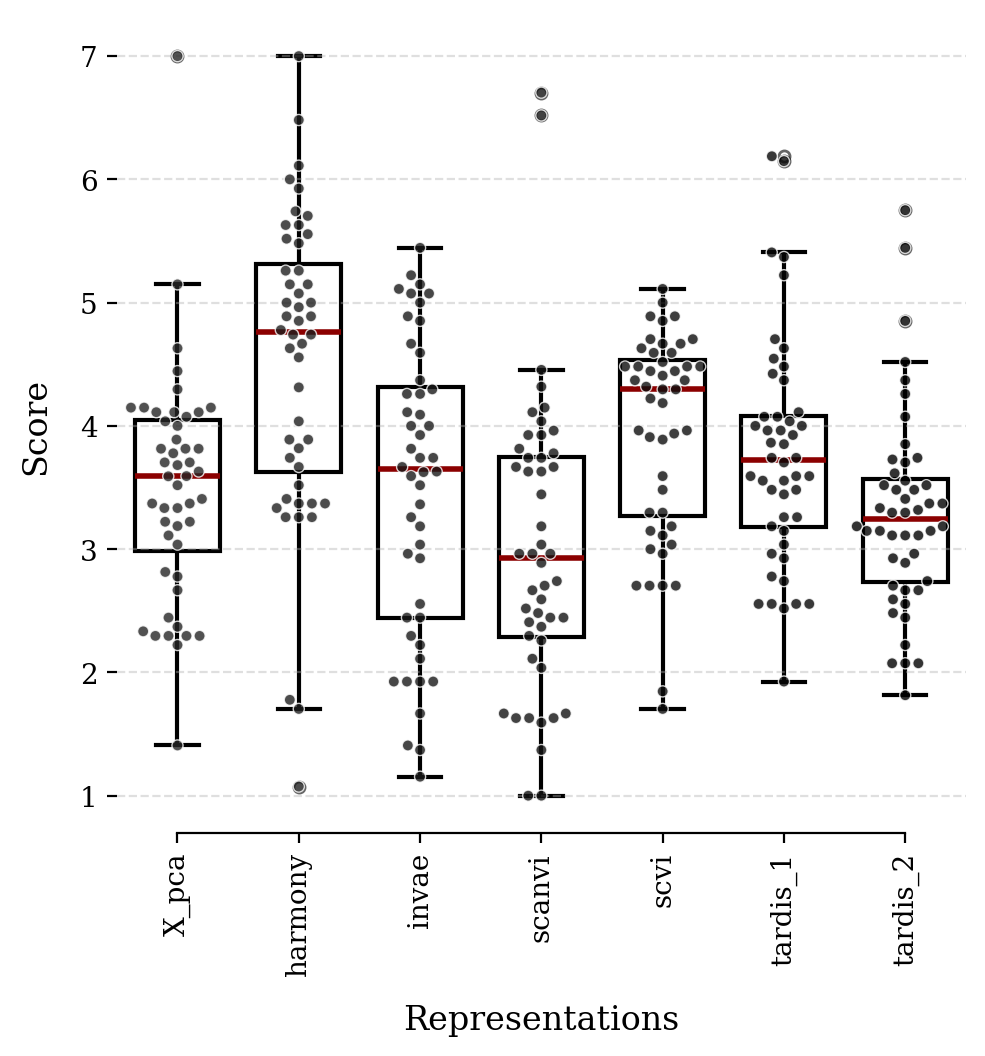

In [144]:
create_dynamic_boxswarm_plot(df_pivot_rank_mean)

### Trajectory-wise Comparison

In [145]:
df_pivot_rank_mean = df_pivot_rank.groupby(level=0).mean()
display(df_pivot_rank_mean)
display(df_pivot_rank_mean.mean())

representation,X_pca,harmony,invae,scanvi,scvi,tardis_1,tardis_2
trajectory,,,,,,,
alternative_myeloid,2.891304,3.282609,3.260870,3.173913,3.369565,4.434783,3.108696
b_cell_specialization,4.270833,3.854167,3.916667,2.583333,3.687500,3.458333,3.750000
b_cells,4.127660,5.553191,3.361702,3.127660,3.446809,3.617021,3.276596
cd4,3.872340,4.595745,3.829787,3.276596,3.340426,3.404255,2.851064
complete_stem_trajectory,3.666667,5.208333,3.479167,2.895833,4.500000,4.104167,3.145833
dendritic,3.276596,4.085106,4.063830,2.446809,4.106383,3.510638,3.723404
early_b_cells,3.217391,4.760870,3.282609,4.130435,3.608696,3.521739,2.630435
early_lymphoid,2.937500,4.645833,3.062500,3.354167,3.145833,3.895833,2.750000
early_stem_trajectory,3.750000,4.666667,4.208333,2.437500,3.875000,2.979167,3.145833


representation
X_pca       3.489667
harmony     4.503749
invae       3.494505
scanvi      3.016296
scvi        3.938747
tardis_1    3.743013
tardis_2    3.267359
dtype: float64

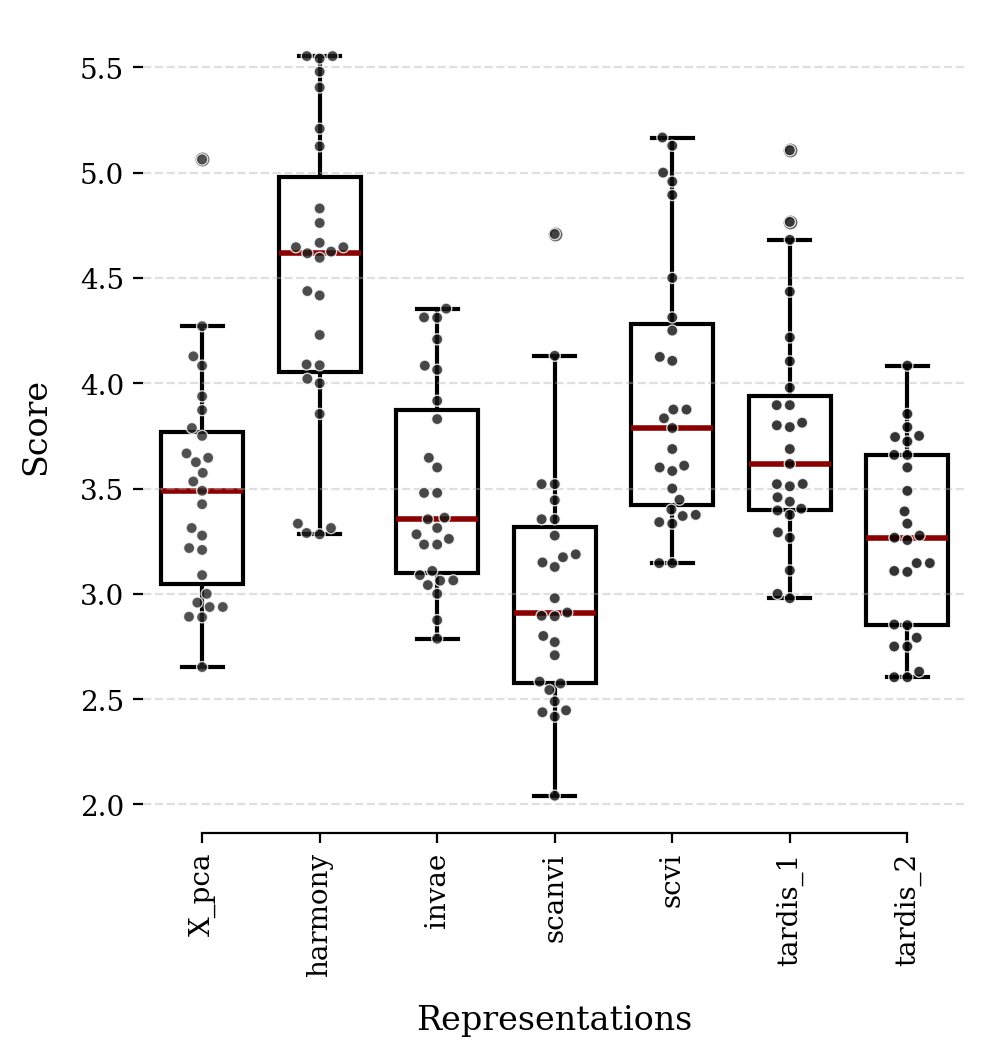

In [146]:
create_dynamic_boxswarm_plot(df_pivot_rank_mean)

In [147]:
# Perform Mann-Whitney U Test for each pair and collect p-values
pairs = list(itertools.permutations(df_pivot_rank_mean.columns, 2))
results = []
for col1, col2 in pairs:
    stat, p_value = stats.mannwhitneyu(df_pivot_rank_mean[col1], df_pivot_rank_mean[col2], alternative='two-sided')
    results.append((col1, col2, stat, p_value))

results_df = pd.DataFrame(results, columns=['Column 1', 'Column 2', 'U Statistic', 'P-Value'])
num_tests = len(results)
results_df['Adjusted P-Value'] = results_df['P-Value'] * num_tests
# display(results_df)

In [148]:
results_df_pivot = results_df.pivot(index='Column 1', columns='Column 2', values='P-Value')
results_df_pivot = results_df_pivot[results_df_pivot.index].round(3)
results_df_pivot

Column 2,X_pca,harmony,invae,scanvi,scvi,tardis_1,tardis_2
Column 1,,,,,,,
X_pca,NaN,0.000,0.883,0.001,0.011,0.085,0.144
harmony,0.000,NaN,0.000,0.000,0.009,0.000,0.000
invae,0.883,0.000,NaN,0.001,0.005,0.065,0.169
scanvi,0.001,0.000,0.001,NaN,0.000,0.000,0.040
scvi,0.011,0.009,0.005,0.000,NaN,0.333,0.000
tardis_1,0.085,0.000,0.065,0.000,0.333,NaN,0.002
tardis_2,0.144,0.000,0.169,0.040,0.000,0.002,NaN


### Path-wise Comparison

In [116]:
df_pivot_rank_mean = df_pivot_rank.groupby(level=1).mean()
display(df_pivot_rank_mean)
display(df_pivot_rank_mean.mean())

representation,X_pca,harmony,invae,scanvi,scvi,tardis_1,tardis_2
path,,,,,,,
adjacency,3.072954,3.937722,2.887900,2.992883,3.498221,3.327402,2.971530
embedding,4.171429,4.907143,3.192857,2.835714,3.882143,4.850000,3.692857
pseudotime,3.601852,4.997685,4.481481,3.162037,4.560185,3.562500,3.372685


representation
X_pca       3.615411
harmony     4.614183
invae       3.520746
scanvi      2.996878
scvi        3.980183
tardis_1    3.913301
tardis_2    3.345691
dtype: float64

## Trajectory Classification

In [177]:
df_pivot = df.pivot(index=['trajectory_class', 'trajectory', 'metric'], columns='representation', values='score')
df_pivot_rank = rank_metrics(df_pivot, metric_direction_dict, metric_index_pos=2, method='min')
df_pivot_rank_mean = df_pivot_rank.groupby(level=0).mean()
display(df_pivot_rank_mean)

representation,X_pca,harmony,invae,scanvi,scvi,tardis_1,tardis_2
trajectory_class,,,,,,,
lymphoid,3.671579,4.686316,3.492632,3.294737,3.633684,3.726316,3.098947
mem,3.064516,3.887097,3.956989,2.763441,4.139785,3.639785,3.747312
myeloid,3.431915,4.402128,3.314894,2.948936,4.008511,3.702128,3.270213
other,3.664336,5.090909,3.496503,2.636364,4.496503,4.055944,3.181818


In [184]:
rank_df(df_pivot_rank_mean, direction="decreasing")

representation,X_pca,harmony,invae,scanvi,scvi,tardis_1,tardis_2
trajectory_class,,,,,,,
lymphoid,5.0,7.0,3.0,2.0,4.0,6.0,1.0
mem,2.0,5.0,6.0,1.0,7.0,3.0,4.0
myeloid,4.0,7.0,3.0,1.0,6.0,5.0,2.0
other,4.0,7.0,3.0,1.0,6.0,5.0,2.0


## Visualization on Trajectory

In [294]:
df_edges = []
for ind, row in df.iterrows():
    trj = lit.get_trajectory(row["trajectory"], False)
    for from_cell, to_cell in trj.edges():
        row_copy = row.copy()
        row_copy["from_cell"] = from_cell
        row_copy["to_cell"] = to_cell
        df_edges.append(row_copy)
df_edges = pd.DataFrame(df_edges)
df_edges.reset_index(drop=True, inplace=True)

In [295]:
df_edges_pivot = df_edges.pivot(index=['path', 'trajectory', 'metric', 'from_cell', 'to_cell'], columns='representation', values='score')
df_edges_pivot_rank = rank_metrics(df_edges_pivot, metric_direction_dict, metric_index_pos=2, method='min')

df_edges_pivot_rank_mean = df_edges_pivot_rank.groupby(level=[3, 4]).mean()
df_edges_pivot_rank_mean

representation                       X_pca   harmony     invae    scanvi  \
from_cell     to_cell                                                      
CD4 T         Regulatory T cells  3.989418  5.275132  3.513228  2.687831   
              Th17                3.989418  5.275132  3.513228  2.687831   
CD5- mature B B1 cells            3.851852  5.084656  3.285714  2.693122   
              Plasma B cells      3.851852  5.084656  3.285714  2.693122   
CD8 T         CD8AA               4.028169  5.500000  3.408451  2.492958   
...                                    ...       ...       ...       ...   
Small pre-B   Immature B          3.588235  5.320856  3.122995  3.074866   
Tab(entry)    CD4 T               3.919831  5.105485  3.540084  2.856540   
              CD8 T               3.931579  5.231579  3.468421  2.752632   
              Cycling T           4.028169  5.500000  3.408451  2.492958   
pDC           Cycling pDC         3.682540  4.899471  3.391534  2.735450   

representation                        scvi  tardis_1  tardis_2  
from_cell     to_cell                                           
CD4 T         Regulatory T cells  4.296296  4.269841  3.089947  
              Th17                4.296296  4.269841  3.089947  
CD5- mature B B1 cells            4.285714  4.232804  3.486772  
              Plasma B cells      4.285714  4.232804  3.486772  
CD8 T         CD8AA               4.612676  4.556338  3.169014  
...                                    ...       ...       ...  
Small pre-B   Immature B          4.272727  4.256684  3.208556  
Tab(entry)    CD4 T               4.109705  4.088608  3.042194  
              CD8 T               4.300000  4.257895  3.089474  
              Cycling T           4.612676  4.556338  3.169014  
pDC           Cycling pDC         4.798942  4.005291  3.513228  

[66 rows x 7 columns]

In [296]:
trj = lit.get_trajectory("haematopoeitic_lineage", False).copy()
for (from_cell, to_cell), representations in df_edges_pivot_rank_mean.iterrows():
    for representation, score in representations.items():
        trj[from_cell][to_cell][f"weight_{representation}"] = score
list(trj[from_cell][to_cell].keys())

['weight_X_pca',
 'weight_harmony',
 'weight_invae',
 'weight_scanvi',
 'weight_scvi',
 'weight_tardis_1',
 'weight_tardis_2']

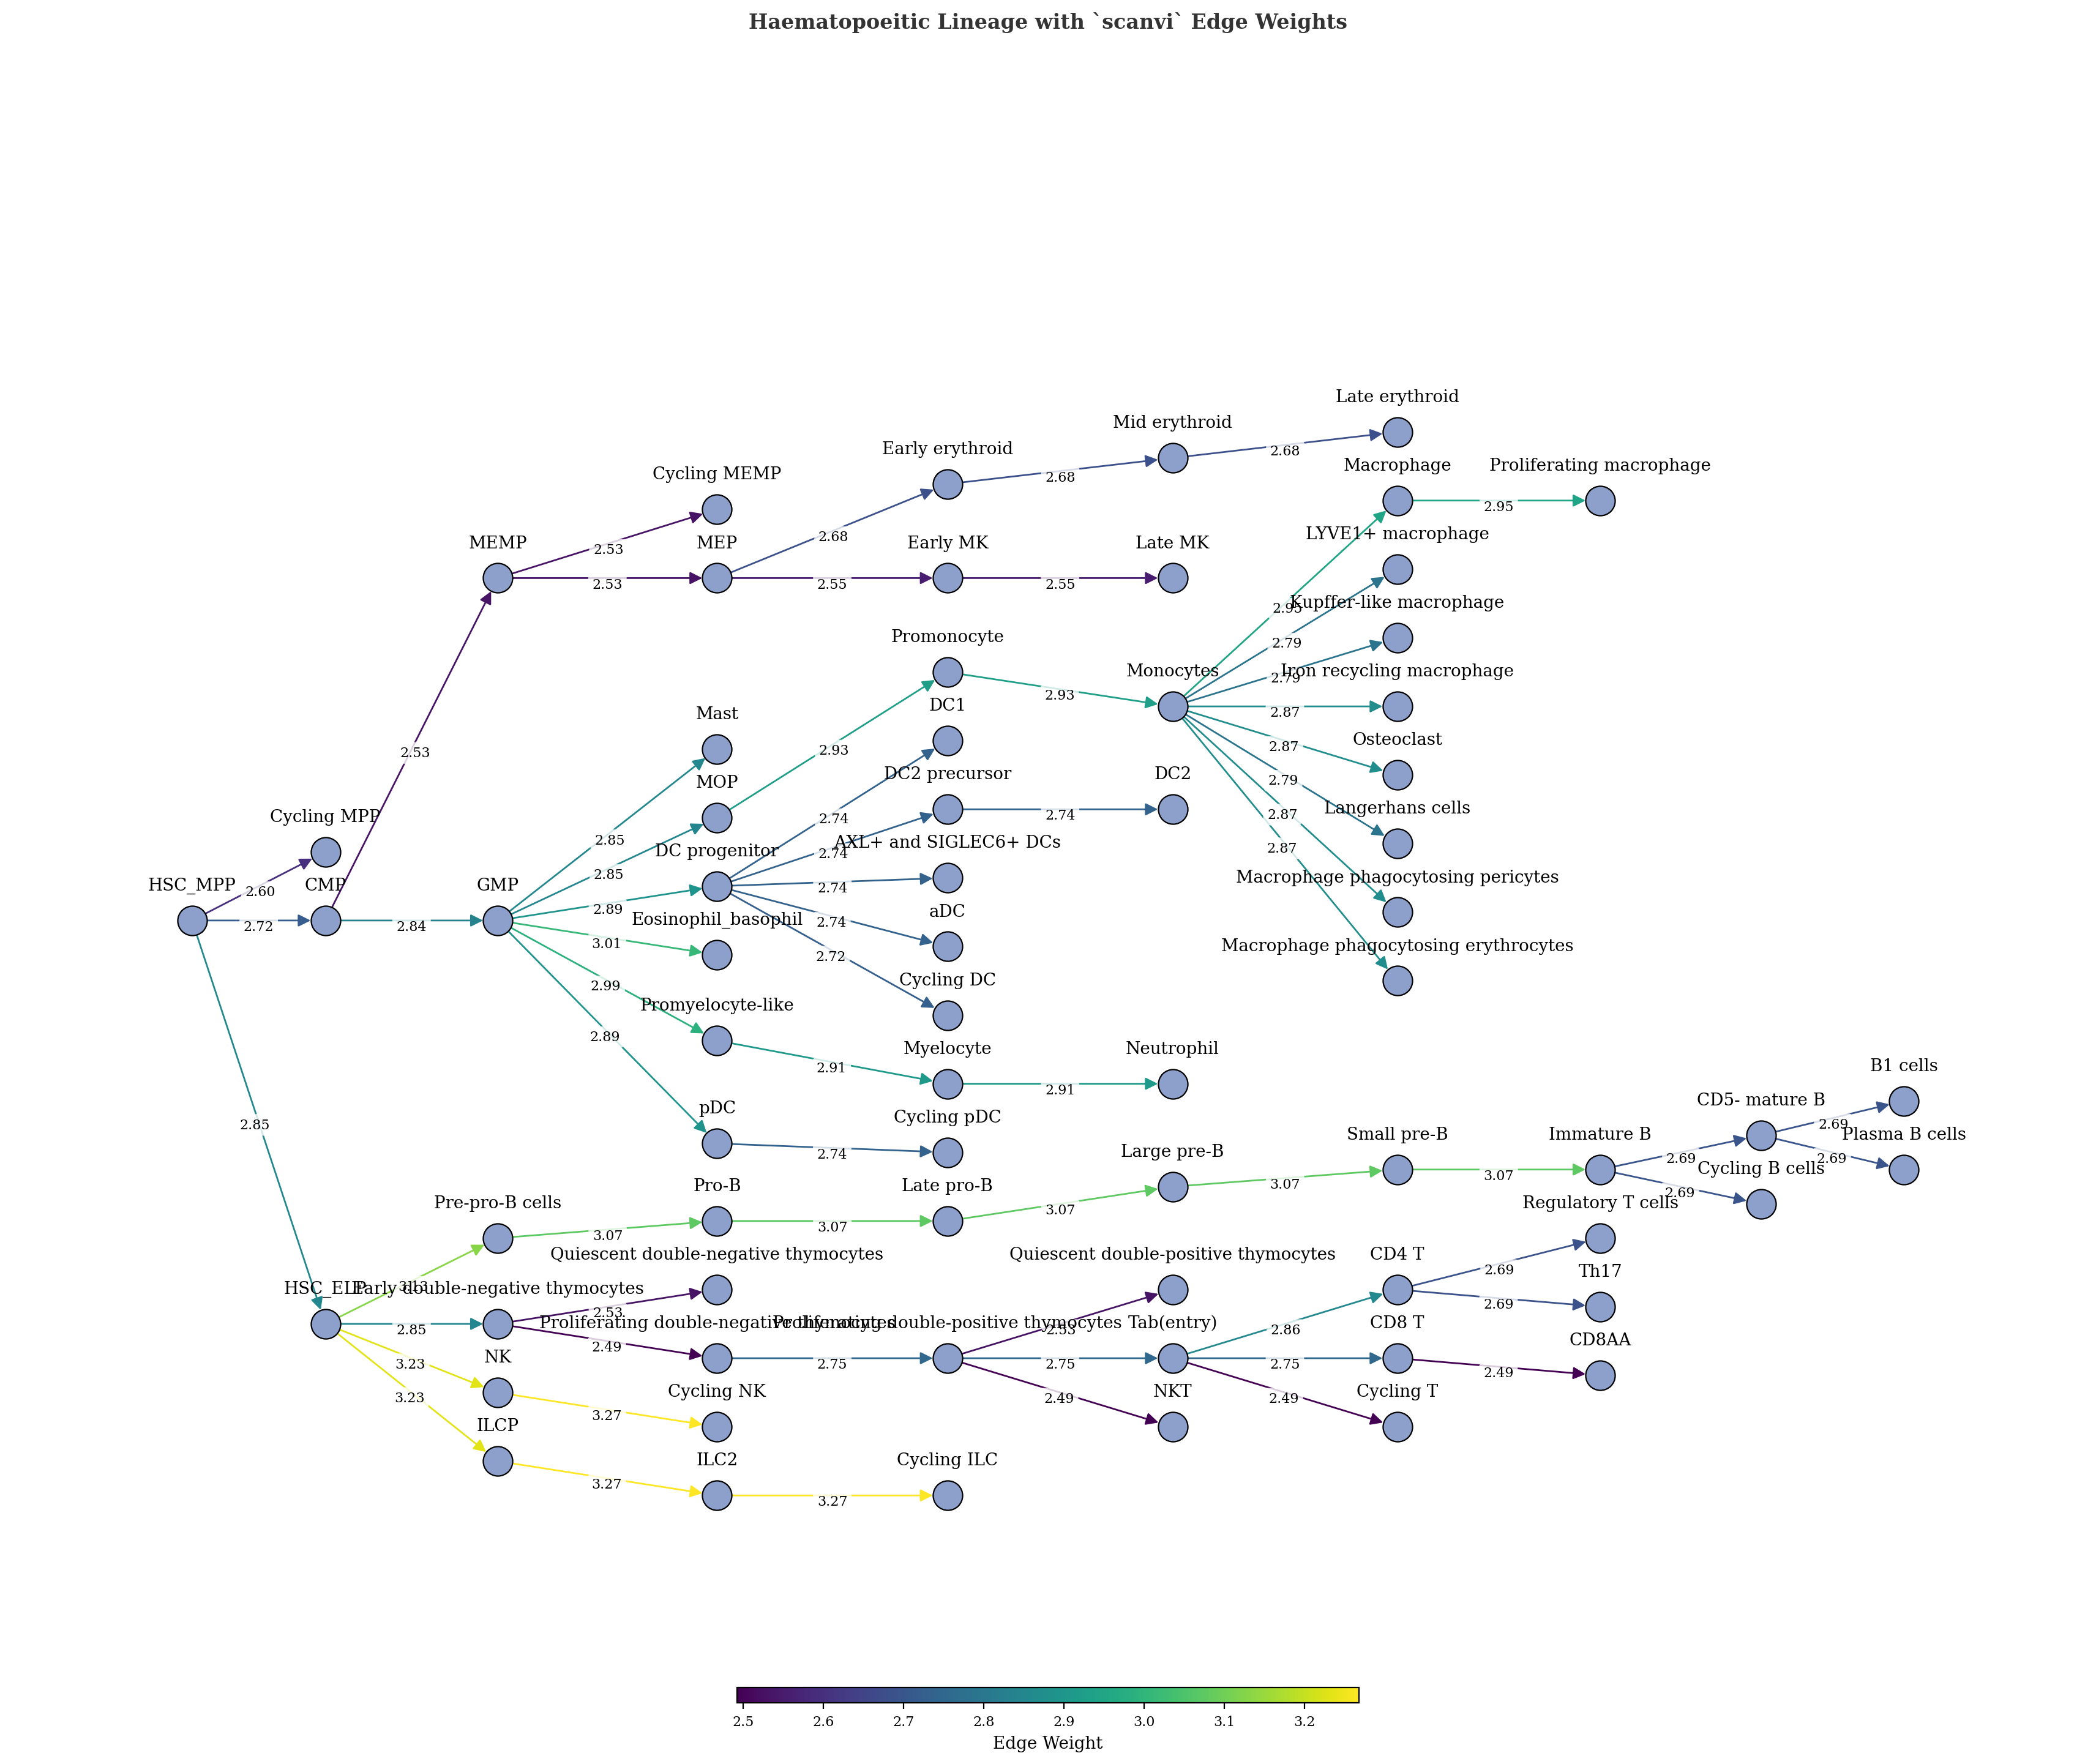

In [303]:
plot_trajectory(
    trj,
    title="Haematopoeitic Lineage with `scanvi` Edge Weights",
    figsize=(18, 18), 
    label_offset=55,
    color_edges_by_weight=True,
    edge_weight_attribute="weight_scanvi",
    edge_labels=True,
    edge_colorbar=True,
    # edge_vmin=1,
    # edge_vmax=4,
    edge_cmap='viridis'
)

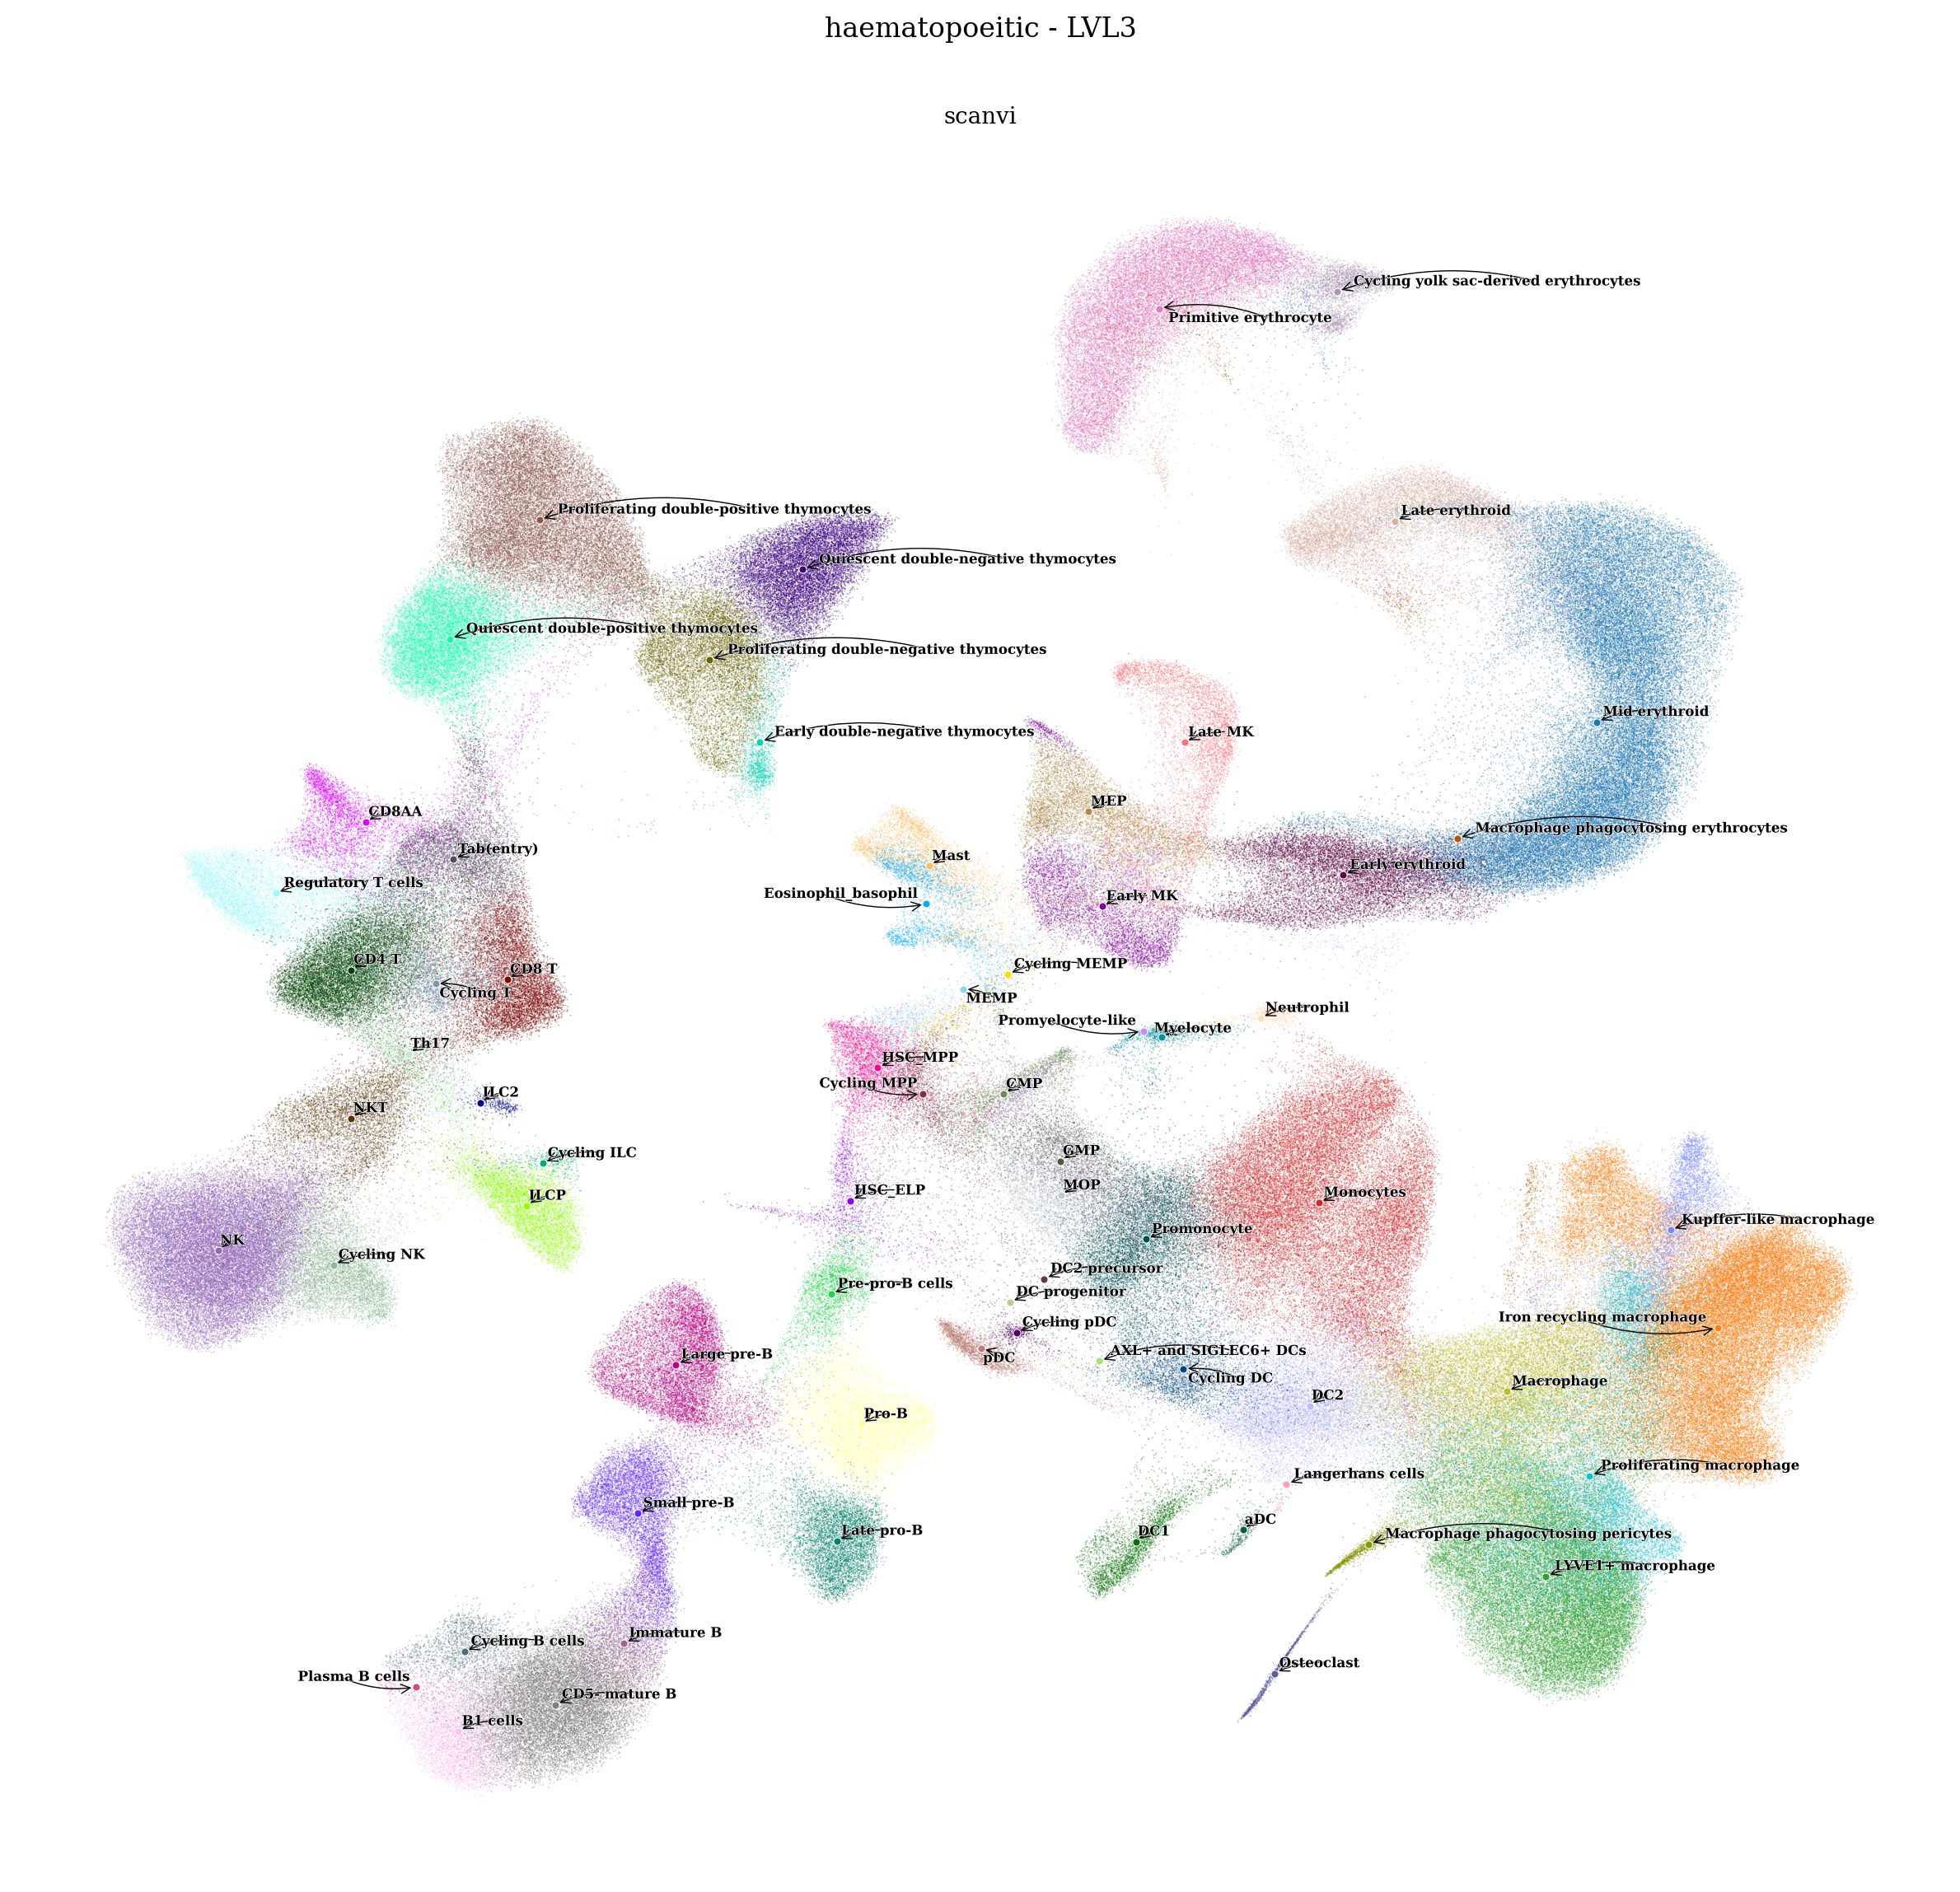

In [304]:
include_obsm = ['scanvi']
lineage = "haematopoeitic"
adata_lineage_subset = {j: {i: adata_lineage[j][i] for i in adata_lineage[j].keys() if i in include_obsm} for j in adata_lineage.keys() if j in [lineage]}
plot_obsms(adata=adata_lineage_subset, lin=lineage, plot_obs="LVL3", label_on_data=True, n_cols=1, subplot_size=(12, 11), coefficient=2.0)

## scIB Styling

In [329]:
df_scib_a = pd.concat([pd.read_pickle("/lustre/groups/ml01/workspace/kemal.inecik/tardis_data/_temporary/latent/suo_scvi_30_latent_scib_bioconservation.pickle"), 
           pd.read_pickle("/lustre/groups/ml01/workspace/kemal.inecik/tardis_data/_temporary/latent/suo_scvi_15_latent_scib_batchcorrection.pickle")], axis=1).T
for l in ["01_01", "01_02", "01_03", "01_04", "01_05", "02_01", "02_02", "02_03", "02_04"]:
    df_scib_b = pd.concat([pd.read_pickle(f"/lustre/groups/ml01/workspace/kemal.inecik/tardis_data/_temporary/latent/suo_v{l}_2_tardis_30_latent_scib_bioconservation.pickle"), 
           pd.read_pickle(f"/lustre/groups/ml01/workspace/kemal.inecik/tardis_data/_temporary/latent/suo_v{l}_2_tardis_15_latent_scib_batchcorrection.pickle")], axis=1).T
    df_scib_a[f"tardis_{l}"] = df_scib_b.loc[df_scib_a.index, "tardis"]
df_scib_b = pd.concat([pd.read_pickle(os.path.join("/lustre/groups/ml01/workspace/kemal.inecik/tardis_data/_temporary", "latent", "suo_scib_scanvi_bio_2.pickle")), 
                  pd.read_pickle(os.path.join("/lustre/groups/ml01/workspace/kemal.inecik/tardis_data/_temporary", "latent", "suo_scib_scanvi_batch_2.pickle"))], axis=1).T
df_scib_a[f"scanvi"] = df_scib_b.loc[df_scib_a.index, "scanvi"]
df_scib_c = pd.concat([pd.read_pickle(os.path.join("/lustre/groups/ml01/workspace/kemal.inecik/tardis_data/_temporary", "latent", "suo_scib_invae_bio.pickle")), 
                  pd.read_pickle(os.path.join("/lustre/groups/ml01/workspace/kemal.inecik/tardis_data/_temporary", "latent", "suo_scib_invae_batch.pickle"))], axis=1).T
invae_models = [i for i in df_scib_c.columns if i.startswith("inveriant")]
df_scib_c = df_scib_c.loc[df_scib_a.index, invae_models]
df_scib_c.columns = ["invae_"+i.split("inveriant_")[1] for i in df_scib_c.columns]
df_scib_a = pd.concat([df_scib_a, df_scib_c], axis=1)
total_score = []
for c in df_scib_a.columns:
    if c != "Metric Type":
        item = 0.4 * df_scib_a[c].loc["Batch correction"] + 0.6 * df_scib_a[c].loc["Bio conservation"]
    else:
        item = "Aggregate score"
    total_score.append(item)
df_scib_a = df_scib_a.T
df_scib_a["Total"] = total_score
df_scib_a = df_scib_a.T
df_scib = df_scib_a.sort_values(by=["Metric Type"], ascending=False)

df_scib = df_scib[["X_pca", "harmony", "scvi", "scanvi", "invae_7", "tardis_01_01", "tardis_02_02"]]
df_scib.rename(columns={"invae_7": "invae", "tardis_01_01": "tardis_1", "tardis_02_02": "tardis_2"}, inplace=True)

# for c in df_scib.columns:
#     if c=="Metric Type":
#         continue
#     df_scib[c] = df_scib[c].apply(lambda x: '{:.3f}'.format(x))

display(df_scib)

,X_pca,harmony,scvi,scanvi,invae,tardis_1,tardis_2
isolated_labels,0.610272,0.563059,0.638389,0.774158,0.798021,0.661863,0.766766
nmi_ari_cluster_labels_kmeans_nmi,0.690709,0.62006,0.648662,0.792213,0.650692,0.633962,0.713115
nmi_ari_cluster_labels_kmeans_ari,0.226331,0.181996,0.20866,0.360095,0.190949,0.184607,0.227751
silhouette_label,0.503657,0.481865,0.496089,0.576235,0.508063,0.496587,0.50828
clisi_knn,0.998818,0.997089,0.998886,0.999928,0.998821,0.997906,0.999242
silhouette_batch,0.850927,0.86237,0.866727,0.860973,0.840279,0.902978,0.895995
ilisi_knn,0.056555,0.099565,0.097533,0.093329,0.040289,0.093512,0.079706
kbet_per_label,0.308528,0.474564,0.487069,0.52572,0.19434,0.448412,0.43022
graph_connectivity,0.793244,0.67147,0.865588,0.911959,0.835844,0.866077,0.878848
pcr_comparison,0.0,0.350362,0.698891,0.222201,0,0.93129,0.849839


In [330]:
# bring sctram here